# OASIS Cross-Sectional Dataset — Exploratory Data Analysis

**Goal:** Explore the OASIS Cross-Sectional dataset to understand its structure, data quality, and feature distributions before building an Alzheimer's Disease classification model.

**Dataset note:** This file does not contain a ready-made `Group` label column. Following the standard OASIS convention, we derive a `Group` label from the Clinical Dementia Rating (`CDR`):
- `CDR = 0` → **Nondemented**
- `CDR > 0` (0.5, 1, 2) → **Demented**
- `CDR` missing → **Unknown** (these subjects were not clinically evaluated for dementia status and should be excluded from classification, but are kept here for completeness)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plot styling for clean, publication-quality figures
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

PALETTE = {"Nondemented": "#2E86AB", "Demented": "#E63946", "Unknown": "#A8A8A8"}


## 1. Load Dataset

In [2]:
DATA_PATH = "oasis_cross-sectional.csv"  # update path if needed

df = pd.read_csv(DATA_PATH)
df.head()


,ID,M/F,Hand,Age,Educ,SES,MMSE,CDR,eTIV,nWBV,ASF,Delay
0,OAS1_0001_MR1,F,R,74,2.0,3.0,29.0,0.0,1344,0.743,1.306,NaN
1,OAS1_0002_MR1,F,R,55,4.0,1.0,29.0,0.0,1147,0.810,1.531,NaN
2,OAS1_0003_MR1,F,R,73,4.0,3.0,27.0,0.5,1454,0.708,1.207,NaN
3,OAS1_0004_MR1,M,R,28,NaN,NaN,NaN,NaN,1588,0.803,1.105,NaN
4,OAS1_0005_MR1,M,R,18,NaN,NaN,NaN,NaN,1737,0.848,1.010,NaN


## 2. Dataset Shape

In [3]:
print(f"Rows (subjects): {df.shape[0]}")
print(f"Columns (features): {df.shape[1]}")


Rows (subjects): 436
Columns (features): 12


**Observation:** The dataset contains 436 subjects and 12 raw columns. This is a relatively small, cross-sectional (single scan per subject) dataset, so we should be mindful of overfitting and use appropriate validation strategies (e.g. stratified k-fold) during modeling.

## 3. Column Information

In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 436 entries, 0 to 435
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ID      436 non-null    str    
 1   M/F     436 non-null    str    
 2   Hand    436 non-null    str    
 3   Age     436 non-null    int64  
 4   Educ    235 non-null    float64
 5   SES     216 non-null    float64
 6   MMSE    235 non-null    float64
 7   CDR     235 non-null    float64
 8   eTIV    436 non-null    int64  
 9   nWBV    436 non-null    float64
 10  ASF     436 non-null    float64
 11  Delay   20 non-null     float64
dtypes: float64(7), int64(2), str(3)
memory usage: 41.0 KB


In [5]:
# Quick look at dtypes and unique value counts per column
summary = pd.DataFrame({
    "dtype": df.dtypes,
    "n_unique": df.nunique(),
    "n_missing": df.isnull().sum()
})
summary


,dtype,n_unique,n_missing
ID,str,436,0
M/F,str,2,0
Hand,str,1,0
Age,int64,73,0
Educ,float64,5,201
SES,float64,5,220
MMSE,float64,17,201
CDR,float64,4,201
eTIV,int64,312,0
nWBV,float64,182,0


**Observation:** Columns fall into three groups:
- **Identifiers/demographics:** `ID`, `M/F`, `Hand`, `Age`, `Educ`, `SES`
- **Clinical scores:** `MMSE` (cognitive test score), `CDR` (clinical dementia rating — our label source)
- **MRI-derived brain measures:** `eTIV` (estimated total intracranial volume), `nWBV` (normalized whole brain volume), `ASF` (atlas scaling factor)
- **Other:** `Delay` (mostly empty, likely a rescan interval field — not useful for modeling)

`Age`, `eTIV` are integers; `Educ`, `SES`, `MMSE`, `CDR`, `nWBV`, `ASF`, `Delay` are floats, several with missing values. `Hand` is nearly constant (almost all subjects are right-handed in OASIS), so it likely carries little predictive value.

## 4. Missing Values

In [6]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_table = pd.DataFrame({"Missing Count": missing, "Missing %": missing_pct})
missing_table = missing_table[missing_table["Missing Count"] > 0].sort_values("Missing %", ascending=False)
missing_table


,Missing Count,Missing %
Delay,416,95.41
SES,220,50.46
Educ,201,46.10
MMSE,201,46.10
CDR,201,46.10


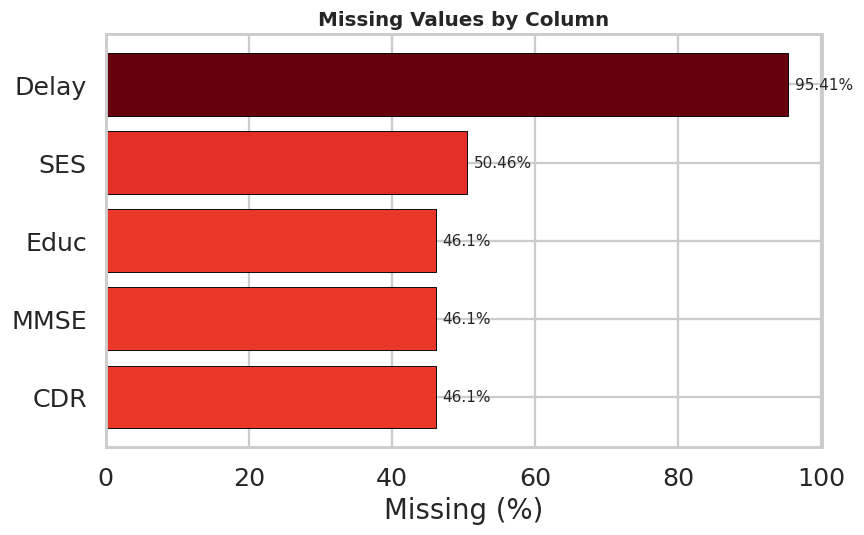

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = plt.cm.Reds(missing_table["Missing %"] / missing_table["Missing %"].max() * 0.7 + 0.3)
ax.barh(missing_table.index, missing_table["Missing %"], color=colors, edgecolor="black", linewidth=0.6)
ax.set_xlabel("Missing (%)")
ax.set_title("Missing Values by Column")
ax.invert_yaxis()
for i, v in enumerate(missing_table["Missing %"]):
    ax.text(v + 1, i, f"{v}%", va="center", fontsize=10)
plt.tight_layout()
plt.show()


**Observation:** `Delay` is missing for the vast majority of subjects (~95%) and offers little value — a strong candidate to drop. `SES`, `Educ`, `MMSE`, and `CDR` are missing for the same ~201–220 subjects, which strongly suggests these subjects simply weren't part of the clinical/cognitive assessment arm of the study (likely the younger, presumed-healthy control subjects who weren't tested for dementia). This needs careful handling: imputing `CDR` would fabricate a diagnosis, so these rows should be excluded from the classification target rather than imputed.

## 5. Duplicate Rows

In [8]:
n_duplicates = df.duplicated().sum()
print(f"Number of fully duplicated rows: {n_duplicates}")

n_duplicate_ids = df['ID'].duplicated().sum()
print(f"Number of duplicate subject IDs: {n_duplicate_ids}")


Number of fully duplicated rows: 0
Number of duplicate subject IDs: 0


**Observation:** No duplicate rows or subject IDs were found, confirming each row represents a unique subject scan with no redundant entries to clean up.

## 6. Descriptive Statistics

In [9]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Age,436.0,51.357798,25.269862,18.000,23.00000,54.000,74.00000,96.000
Educ,235.0,3.178723,1.311510,1.000,2.00000,3.000,4.00000,5.000
SES,216.0,2.490741,1.120593,1.000,2.00000,2.000,3.00000,5.000
MMSE,235.0,27.063830,3.696870,14.000,26.00000,29.000,30.00000,30.000
CDR,235.0,0.285106,0.383405,0.000,0.00000,0.000,0.50000,2.000
eTIV,436.0,1481.919725,158.740866,1123.000,1367.75000,1475.500,1579.25000,1992.000
nWBV,436.0,0.791670,0.059937,0.644,0.74275,0.809,0.84200,0.893
ASF,436.0,1.198894,0.128682,0.881,1.11175,1.190,1.28425,1.563
Delay,20.0,20.550000,23.862490,1.000,2.75000,11.000,30.75000,89.000


In [4]:
# Categorical columns
df.describe(include='object').T


,count,unique,top,freq
ID,436,436,OAS1_0001_MR1,1
M/F,436,2,F,268
Hand,436,1,R,436


**Observation:** `Age` ranges broadly (likely late teens/20s through 90s), reflecting OASIS's deliberate inclusion of both young healthy controls and older adults with possible dementia. `MMSE` scores cluster near the high end (close to 30, the maximum), consistent with most clinically-assessed subjects being cognitively normal or mildly impaired. `nWBV` (normalized brain volume) shows the kind of spread expected with aging-related atrophy. `Hand` shows almost all subjects are right-handed, confirming it's unlikely to be a useful feature.

## 7. Class Distribution (Group, derived from CDR)

In [11]:
def cdr_to_group(cdr):
    if pd.isna(cdr):
        return "Unknown"
    elif cdr == 0:
        return "Nondemented"
    else:
        return "Demented"

df["Group"] = df["CDR"].apply(cdr_to_group)

group_counts = df["Group"].value_counts()
group_pct = (group_counts / len(df) * 100).round(1)
pd.DataFrame({"Count": group_counts, "Percentage": group_pct})


,Count,Percentage
Group,,
Unknown,201,46.1
Nondemented,135,31.0
Demented,100,22.9


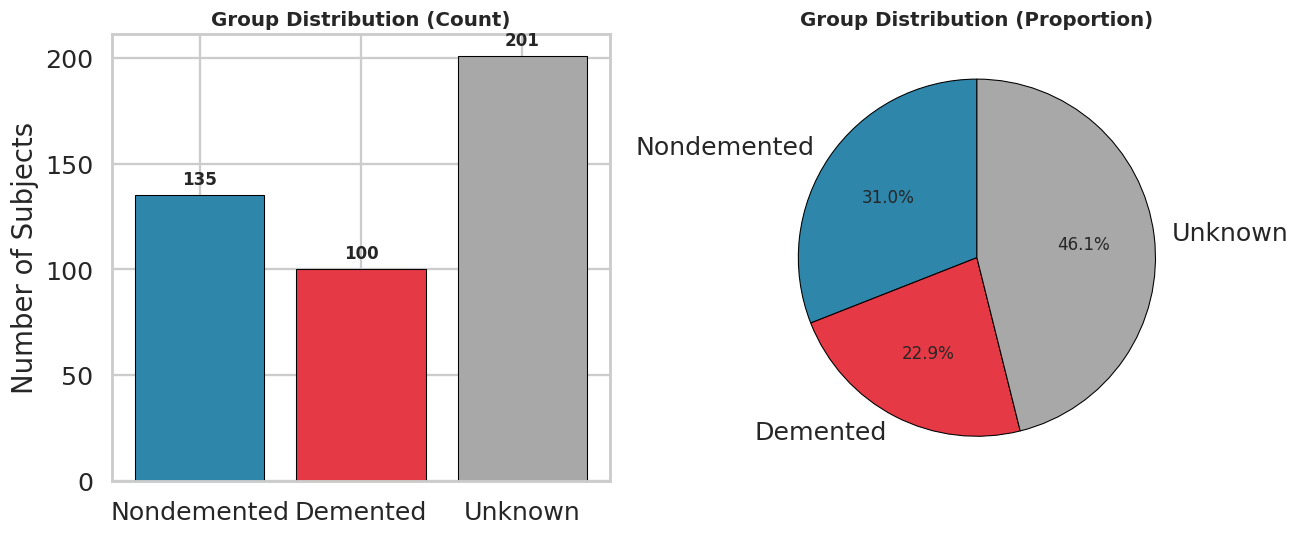

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

order = ["Nondemented", "Demented", "Unknown"]
colors = [PALETTE[g] for g in order]

axes[0].bar(order, group_counts.reindex(order), color=colors, edgecolor="black", linewidth=0.7)
axes[0].set_title("Group Distribution (Count)")
axes[0].set_ylabel("Number of Subjects")
for i, v in enumerate(group_counts.reindex(order)):
    axes[0].text(i, v + 5, str(v), ha="center", fontweight="bold")

axes[1].pie(group_counts.reindex(order), labels=order, autopct="%1.1f%%",
            colors=colors, startangle=90, wedgeprops={"edgecolor": "black", "linewidth": 0.7})
axes[1].set_title("Group Distribution (Proportion)")

plt.tight_layout()
plt.show()


**Observation:** Among subjects with a recorded CDR, Nondemented subjects substantially outnumber Demented subjects, indicating class imbalance that will need addressing during modeling (e.g. class weighting, SMOTE, or stratified sampling). Roughly 46% of subjects have `CDR = NaN` ("Unknown") — these are likely young healthy controls without clinical dementia assessment, and should be excluded when training a Demented vs. Nondemented classifier.

## 8. Publication-Quality Plots

### 8.1 Age Distribution by Group

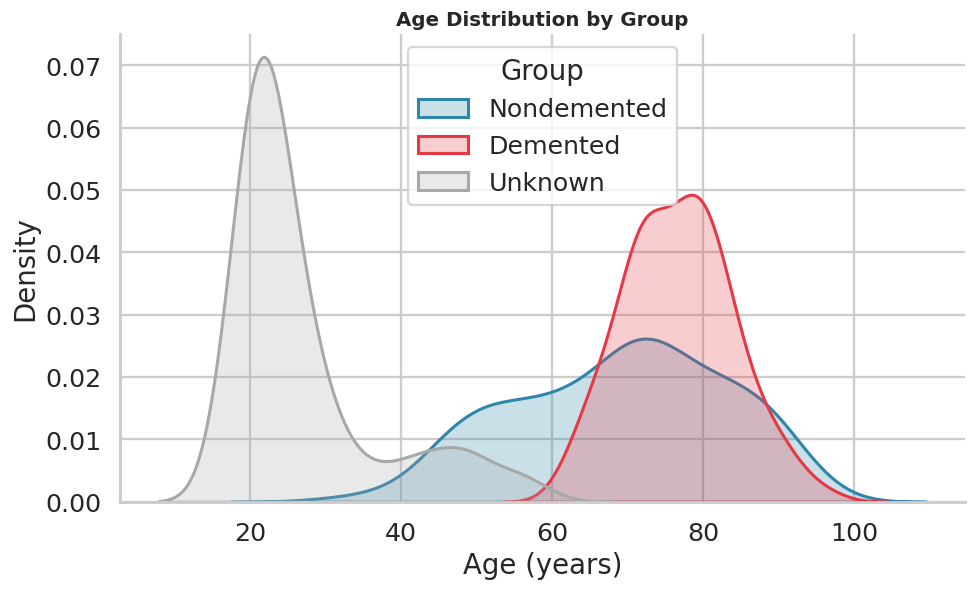

In [13]:
fig, ax = plt.subplots(figsize=(9, 5.5))
for grp in ["Nondemented", "Demented", "Unknown"]:
    subset = df[df["Group"] == grp]
    sns.kdeplot(subset["Age"], label=grp, fill=True, alpha=0.25, linewidth=2,
                color=PALETTE[grp], ax=ax)
ax.set_title("Age Distribution by Group")
ax.set_xlabel("Age (years)")
ax.set_ylabel("Density")
ax.legend(title="Group", frameon=True)
sns.despine()
plt.tight_layout()
plt.show()


**Observation:** The clear bimodal pattern reflects OASIS's design: a young/middle-aged "Unknown" group (no dementia assessment performed) and an older group spanning Nondemented and Demented. Within the clinically assessed population, Demented subjects skew toward older ages, consistent with dementia risk increasing with age.

### 8.2 MMSE Score by Group

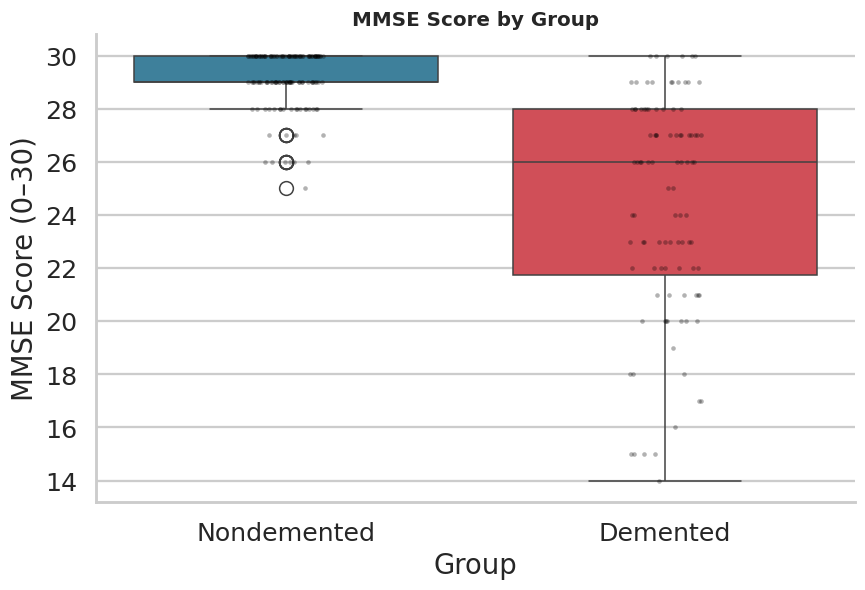

In [14]:
fig, ax = plt.subplots(figsize=(8, 5.5))
plot_df = df[df["Group"] != "Unknown"]
sns.boxplot(data=plot_df, x="Group", y="MMSE", hue="Group",
            palette=PALETTE, order=["Nondemented", "Demented"], legend=False, ax=ax)
sns.stripplot(data=plot_df, x="Group", y="MMSE", order=["Nondemented", "Demented"],
              color="black", alpha=0.3, size=3, ax=ax)
ax.set_title("MMSE Score by Group")
ax.set_ylabel("MMSE Score (0–30)")
sns.despine()
plt.tight_layout()
plt.show()


**Observation:** Demented subjects show markedly lower and more variable MMSE scores than Nondemented subjects, with limited overlap. This confirms MMSE as one of the strongest individual predictors of dementia status — unsurprising, since MMSE is itself a cognitive screening tool, but important to note as it may dominate a model if not handled carefully (risk of label leakage if CDR-MMSE relationship is too direct).

### 8.3 Brain Volume (nWBV) by Group and Age

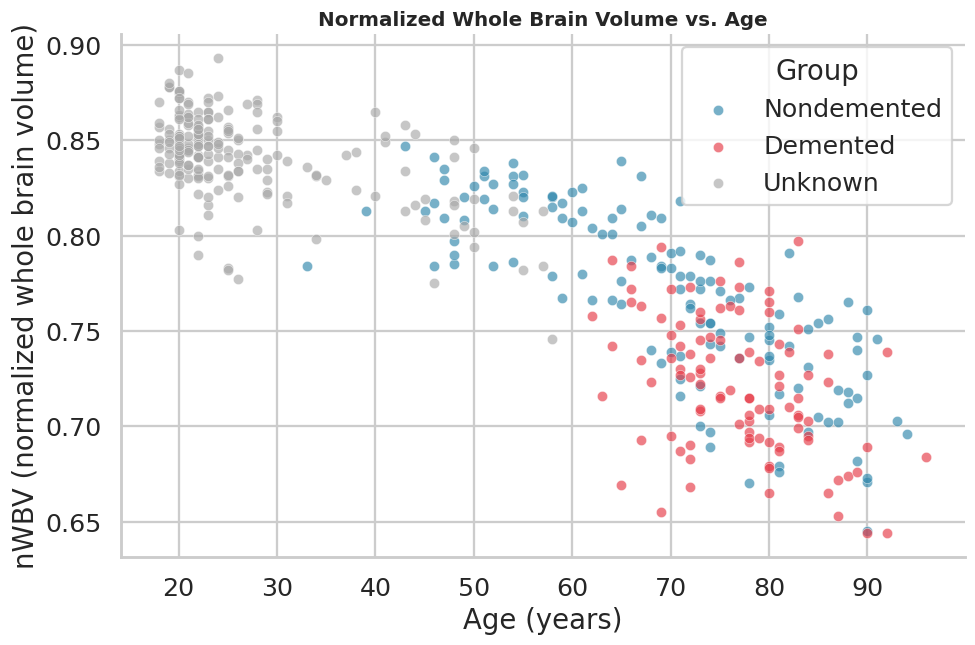

In [15]:
fig, ax = plt.subplots(figsize=(9, 6))
for grp in ["Nondemented", "Demented", "Unknown"]:
    subset = df[df["Group"] == grp]
    ax.scatter(subset["Age"], subset["nWBV"], label=grp, color=PALETTE[grp],
               alpha=0.65, s=45, edgecolor="white", linewidth=0.4)
ax.set_title("Normalized Whole Brain Volume vs. Age")
ax.set_xlabel("Age (years)")
ax.set_ylabel("nWBV (normalized whole brain volume)")
ax.legend(title="Group", frameon=True)
sns.despine()
plt.tight_layout()
plt.show()


**Observation:** `nWBV` declines with age across all groups, consistent with natural brain atrophy. Demented subjects tend to sit lower on the nWBV axis than Nondemented subjects of similar age, suggesting accelerated atrophy is a meaningful structural signature of dementia and a useful model feature — not just age acting as a confound.

### 8.4 Feature Correlation Heatmap

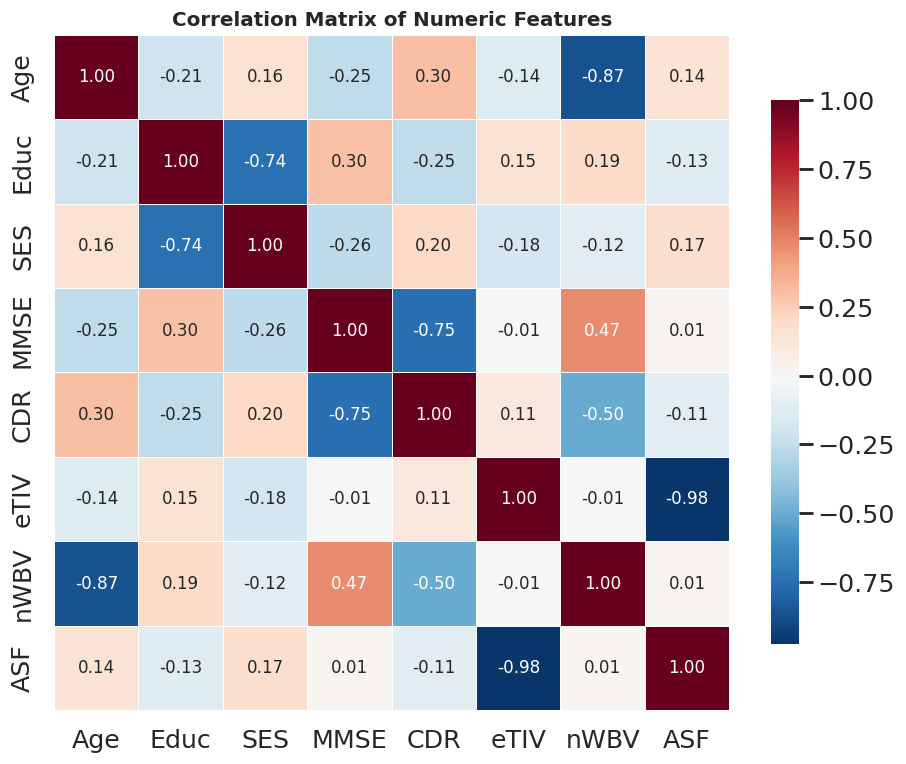

In [16]:
numeric_cols = ["Age", "Educ", "SES", "MMSE", "CDR", "eTIV", "nWBV", "ASF"]
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8.5, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Correlation Matrix of Numeric Features")
plt.tight_layout()
plt.show()


**Observation:** `eTIV` and `ASF` are strongly (negatively) correlated, since ASF is a scaling factor derived directly from intracranial volume — including both as model features would introduce redundancy. `CDR` correlates negatively with `MMSE` (expected, since lower cognitive scores indicate higher dementia severity) and negatively with `nWBV` (atrophy linked to dementia). `Age` shows the expected negative relationship with `nWBV`. These relationships justify nWBV, MMSE, and Age as core features, while suggesting eTIV/ASF redundancy should be resolved before modeling.

### 8.5 Gender Distribution by Group

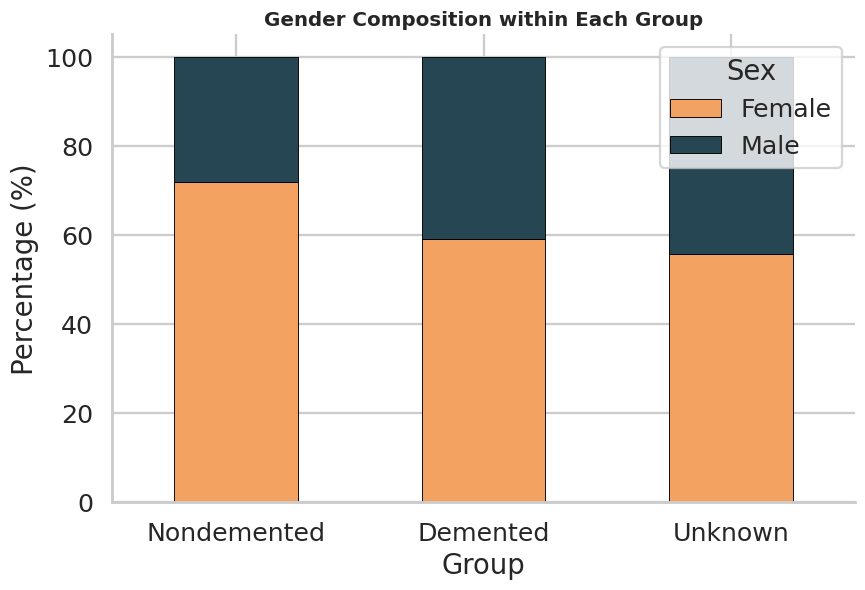

In [17]:
ct = pd.crosstab(df["Group"], df["M/F"])
ct = ct.reindex(["Nondemented", "Demented", "Unknown"])
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(8, 5.5))
ct_pct.plot(kind="bar", stacked=True, color=["#F4A261", "#264653"], edgecolor="black",
            linewidth=0.6, ax=ax)
ax.set_title("Gender Composition within Each Group")
ax.set_ylabel("Percentage (%)")
ax.set_xlabel("Group")
ax.legend(title="Sex", labels=["Female", "Male"])
plt.xticks(rotation=0)
sns.despine()
plt.tight_layout()
plt.show()


**Observation:** Compare the male/female split across groups to check for sampling imbalance. If one sex is disproportionately represented among Demented subjects, this is worth flagging — it may reflect genuine epidemiology (dementia prevalence differs slightly by sex) or a sampling artifact in how OASIS recruited clinical subjects, and should inform whether sex is used as a model feature or only as a stratification variable.

## 9. Summary of Key Observations

1. **Dataset size:** 436 subjects, 12 raw features — small for deep learning, well-suited to classical ML with careful cross-validation.
2. **No `Group` column exists in the raw file** — it must be derived from `CDR` (Nondemented / Demented / Unknown), and ~46% of subjects fall into "Unknown" (no clinical dementia assessment) and should be excluded from the classification target.
3. **Missingness is structured, not random:** `SES`, `Educ`, `MMSE`, `CDR` are missing together for the same subset of subjects (the non-clinically-assessed group) — this should not be imputed for `CDR` since it would fabricate diagnostic labels. `Delay` is almost entirely missing and should be dropped.
4. **No duplicate rows or subject IDs** — no deduplication needed.
5. **Class imbalance:** Within the clinically labeled subset, Nondemented subjects outnumber Demented subjects — plan for class weighting or resampling.
6. **Strong predictive signals:** `MMSE` and `nWBV` both show clear separation between Demented and Nondemented groups; `Age` is a relevant covariate; `eTIV`/`ASF` are redundant with each other.
7. **Low-value features:** `Hand` is nearly constant across subjects and likely uninformative; `Delay` is mostly missing.

**Next steps:** drop `Delay`, resolve `eTIV`/`ASF` redundancy, restrict the modeling subset to subjects with known `CDR`, address class imbalance, and proceed to feature engineering / baseline model training.
